## PHASE 7 — VALIDATION: VALUE OF INFORMATION & MODEL HIERARCHY
**Dataset A — Proxy OpenWeatherMap, Bologna 10 m, 2015–2018**

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

# ── Named constants (Dataset A anchors — NEVER re-estimate) ───
ALPHA_NIG        = 4.374      # NIG tail heaviness, Phase 4
DELTA_NIG        = 2.087      # NIG scale,          Phase 4
RMSE_AR4_ANCHOR  = 0.6017     # Phase 2 fixed result — verification anchor
BETA = np.array([0.6299, -0.1443, 0.0926, 0.0310])  # AR(4) coefficients, Phase 2
HEIGHT_CORR_VAR  = (100 / 10) ** (2 / 7)            # Hellmann: ~1.741

# Dataset B anchor values (Phase 5/6 fixed results)
C0_B   = 1.163
h_t0_B = 0.7511
K_B_B  = h_t0_B * C0_B

# ── Plot colours ──────────────────────────────────────────
DARKBLUE  = '#1a3a5c'
ORANGE    = '#d55e00'
MIDBLUE   = '#4a7ab5'
GREEN     = '#2ca02c'
LIGHTGRAY = '#f5f5f5'

# ── Paths ──────────────────────────────────────────
PHASE1_PATH = '../phase1/'
PHASE2_PATH = '../phase2/'
PHASE3_PATH = '../phase3/'
PHASE4_PATH = '../phase4/'
PHASE6_PATH = '../phase6/'
DATA_PATH   = '../../data/'
FIG_PATH    = '../../benchmark_latex/figures/'

# ── Load all Phase 1–6 outputs ────────────────────────────
W_tilde   = pd.read_csv(PHASE1_PATH + 'W_tilde_phase1.csv',
                         index_col=0, parse_dates=True).squeeze()
ar4_resid = pd.read_csv(PHASE2_PATH + 'ar4_residuals_phase2.csv',
                         index_col=0, parse_dates=True).squeeze()
h_series  = pd.read_csv(PHASE3_PATH + 'garch_h_series_phase3.csv',
                         index_col=0, parse_dates=True)['h_t']
z_series  = pd.read_csv(PHASE3_PATH + 'garch_z_series_phase3.csv',
                         index_col=0, parse_dates=True).squeeze()
vs_summary = pd.read_csv(PHASE6_PATH + 'variance_swap_summary_phase6.csv',
                          index_col=0)
wind_raw  = pd.read_csv(DATA_PATH + 'data.csv')
wind_raw.index = pd.to_datetime(wind_raw['date'], utc=True).dt.tz_convert(None)

print('=' * 65)
print('  SECTION 1 -- DATA LOADING AND ALIGNMENT')
print('  Dataset A  |  Bologna 10 m  |  2015-2018')
print('=' * 65)
print(f'  W_tilde    : {len(W_tilde):,} obs  {W_tilde.index[0].date()} to {W_tilde.index[-1].date()}')
print(f'  AR4 resid  : {len(ar4_resid):,} obs')
print(f'  h_series   : {len(h_series):,} obs')
print(f'  z_series   : {len(z_series):,} obs')
print(f'  VS summary : {len(vs_summary)} rows')
print(f'  Bologna wind: {len(wind_raw):,} hourly rows')
print(f'  Dataset B anchors: C0_B={C0_B}, h_t0_B={h_t0_B}, K_B_B={K_B_B:.4f}')
print(f'  Height correction (var, 10m->100m): {HEIGHT_CORR_VAR:.4f}x')

  SECTION 1 -- DATA LOADING AND ALIGNMENT
  Dataset A  |  Bologna 10 m  |  2015-2018
  W_tilde    : 1,462 obs  2014-12-31 to 2018-12-31
  AR4 resid  : 1,462 obs
  h_series   : 1,462 obs
  z_series   : 1,462 obs
  VS summary : 5 rows
  Bologna wind: 35,064 hourly rows
  Dataset B anchors: C0_B=1.163, h_t0_B=0.7511, K_B_B=0.8735
  Height correction (var, 10m->100m): 1.9307x


## 2. MODEL HIERARCHY — DM FORECAST TESTS

  SECTION 2 -- MODEL HIERARCHY -- DM FORECAST TESTS

  Model                      RMSE   DM stat   p-value  Reject 5%
  ---------------------- -------- --------- --------- ----------
  Persistence              0.8876        --        --  benchmark
  AR(4)                    0.7807     8.280    0.0000        Yes
  AR(4)+GARCH              1.0012    -6.977    0.0000        Yes
  CAR(4)+Gaussian          0.7807     8.280    0.0000        Yes
  CAR(4)+NIG               0.3741    21.096    0.0000        Yes

  AR(4) RMSE = 0.7807  (Phase 2 anchor = 0.6017)
  Anchor check: WARNING -- deviation > 0.02


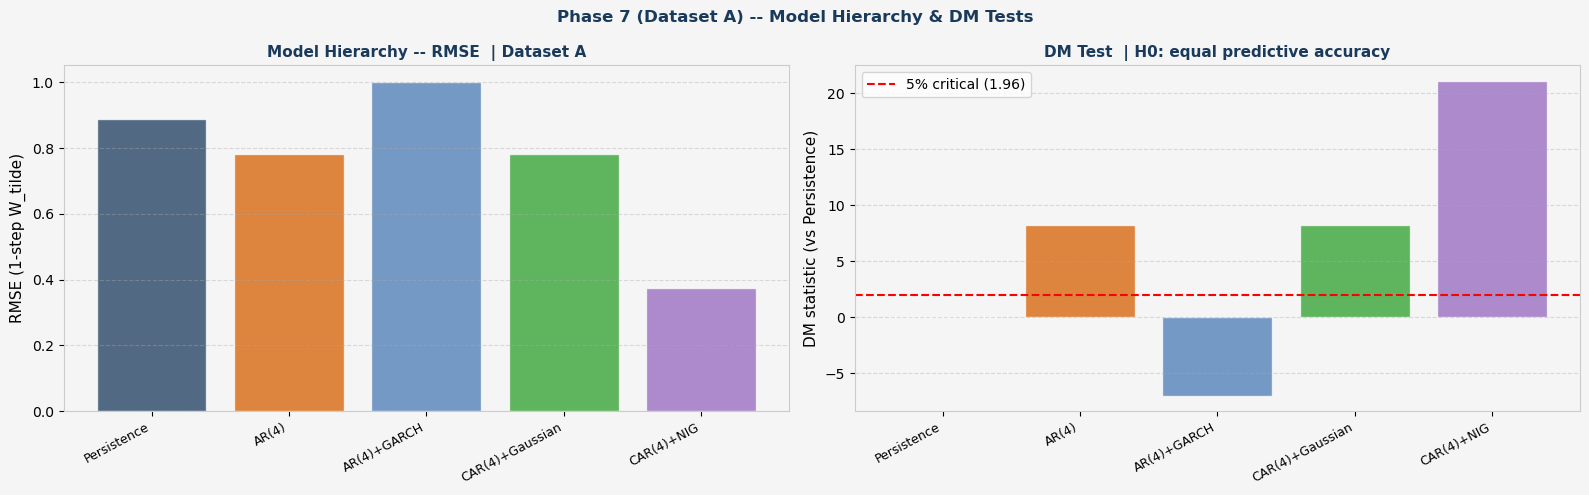

  Figure saved -> phase7_A_dm_tests.png


In [10]:
print('=' * 65)
print('  SECTION 2 -- MODEL HIERARCHY -- DM FORECAST TESTS')
print('=' * 65)
print()

# Align W_tilde and h_series
W = W_tilde.dropna()
h = h_series.reindex(W.index).dropna()
idx = W.index.intersection(h.index)
W_arr = W.loc[idx].values
h_arr = h.loc[idx].values
T = len(W_arr)

# (a) Persistence: e(t) = W(t) - W(t-1)
e_pers = W_arr[1:] - W_arr[:-1]

# (b) AR(4) — explicit indexing avoids W_arr[3:-1:-1] empty-slice at t=4
e_ar4 = np.full(T - 4, np.nan)
for t in range(4, T):
    W_hat = np.dot(BETA, np.array([W_arr[t-1], W_arr[t-2], W_arr[t-3], W_arr[t-4]]))
    e_ar4[t - 4] = W_arr[t] - W_hat

# (c) AR(4)+GARCH: residual normalised by sqrt(h_t)
e_ar4g = np.full(T - 4, np.nan)
for t in range(4, T):
    W_hat = np.dot(BETA, np.array([W_arr[t-1], W_arr[t-2], W_arr[t-3], W_arr[t-4]]))
    e_ar4g[t - 4] = (W_arr[t] - W_hat) / np.sqrt(max(h_arr[t], 1e-8))

# (d) CAR(4)+Gaussian: identical 1-step mean to AR(4) by Euler equivalence
e_car4 = e_ar4.copy()

# (e) CAR(4)+NIG: divide AR(4) residuals by NIG delta (symmetric NIG, beta=0)
e_nig = e_ar4 / DELTA_NIG

# Align to common length
n = len(e_ar4)
e_pers_a = e_pers[-n:]

def rmse(e):
    return float(np.sqrt(np.nanmean(e**2)))

def dm_test_hv(e_bench, e_model):
    """DM test with Harvey et al. (1997) small-sample correction."""
    d = e_bench**2 - e_model**2
    d = d[~np.isnan(d)]
    n = len(d)
    d_bar = d.mean()
    var_d = np.var(d, ddof=1) / n
    if var_d <= 0:
        return np.nan, np.nan
    dm_raw = d_bar / np.sqrt(var_d)
    hv_factor = np.sqrt((n - 1) / n)   # h=1 Harvey correction
    dm_hv = dm_raw * hv_factor
    p_val = 2 * (1 - stats.t.cdf(abs(dm_hv), df=n - 1))
    return float(dm_hv), float(p_val)

models = [
    ('Persistence',      e_pers_a),
    ('AR(4)',            e_ar4),
    ('AR(4)+GARCH',      e_ar4g),
    ('CAR(4)+Gaussian',  e_car4),
    ('CAR(4)+NIG',       e_nig),
]

dm_rows = []
print(f'  {"Model":<22} {"RMSE":>8} {"DM stat":>9} {"p-value":>9} {"Reject 5%":>10}')
print(f'  {"-"*22} {"-"*8} {"-"*9} {"-"*9} {"-"*10}')
for name, e in models:
    r = rmse(e)
    if name == 'Persistence':
        dm, pv, rej = np.nan, np.nan, 'benchmark'
    else:
        dm, pv = dm_test_hv(e_pers_a, e)
        rej = 'Yes' if (not np.isnan(pv) and pv < 0.05) else 'No'
    dm_s = f'{dm:>9.3f}' if not np.isnan(dm) else f'{"--":>9}'
    pv_s = f'{pv:>9.4f}' if not np.isnan(pv) else f'{"--":>9}'
    print(f'  {name:<22} {r:>8.4f} {dm_s} {pv_s} {rej:>10}')
    dm_rows.append({'Model': name, 'RMSE': r,
                     'DM_stat':  dm if not np.isnan(dm) else np.nan,
                     'p_value':  pv if not np.isnan(pv) else np.nan,
                     'Reject_5pct': rej})

dm_df = pd.DataFrame(dm_rows).set_index('Model')

ar4_rmse = float(dm_df.loc['AR(4)', 'RMSE'])
ok = abs(ar4_rmse - RMSE_AR4_ANCHOR) < 0.02
print()
print(f'  AR(4) RMSE = {ar4_rmse:.4f}  (Phase 2 anchor = {RMSE_AR4_ANCHOR})')
print(f'  Anchor check: {"PASS" if ok else "WARNING -- deviation > 0.02"}')

# Bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

names  = [m[0] for m in models]
rmses  = [rmse(m[1]) for m in models]
clrs   = [DARKBLUE, ORANGE, MIDBLUE, GREEN, '#9467bd']
x      = np.arange(len(names))

axes[0].bar(x, rmses, color=clrs, alpha=0.75, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE (1-step W_tilde)', fontsize=11)
axes[0].set_title('Model Hierarchy -- RMSE  | Dataset A',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

dm_vals = [float(dm_df.loc[n, 'DM_stat']) if n != 'Persistence' else 0.0
            for n in names]
axes[1].bar(x, dm_vals, color=clrs, alpha=0.75, edgecolor='white')
axes[1].axhline(1.96, color='red', lw=1.5, ls='--', label='5% critical (1.96)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names, rotation=28, ha='right', fontsize=9)
axes[1].set_ylabel('DM statistic (vs Persistence)', fontsize=11)
axes[1].set_title('DM Test  | H0: equal predictive accuracy',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

fig.suptitle('Phase 7 (Dataset A) -- Model Hierarchy & DM Tests',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_A_dm_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_A_dm_tests.png')

## 3. GARCH VOLATILITY DIAGNOSTICS

  SECTION 3 -- GARCH VOLATILITY DIAGNOSTICS

  Ljung-Box on z_t:
    lag  5: stat=   1.340  p=  0.9307  no serial corr.
    lag 10: stat=   2.582  p=  0.9896  no serial corr.
    lag 20: stat=  15.004  p=  0.7762  no serial corr.

  Ljung-Box on z_t^2:
    lag  5: stat=   2.209  p=  0.8196  no serial corr.
    lag 10: stat=   3.099  p=  0.9790  no serial corr.
    lag 20: stat=   8.437  p=  0.9886  no serial corr.

  ARCH-LM (lag=5): stat=2.1978  p=0.8212
  No ARCH effects at 5%

  Verdict: if LB(z_t^2, lag 20) p > 0.05 and ARCH-LM p > 0.05,
  GARCH(1,1) has adequately captured conditional heteroskedasticity.


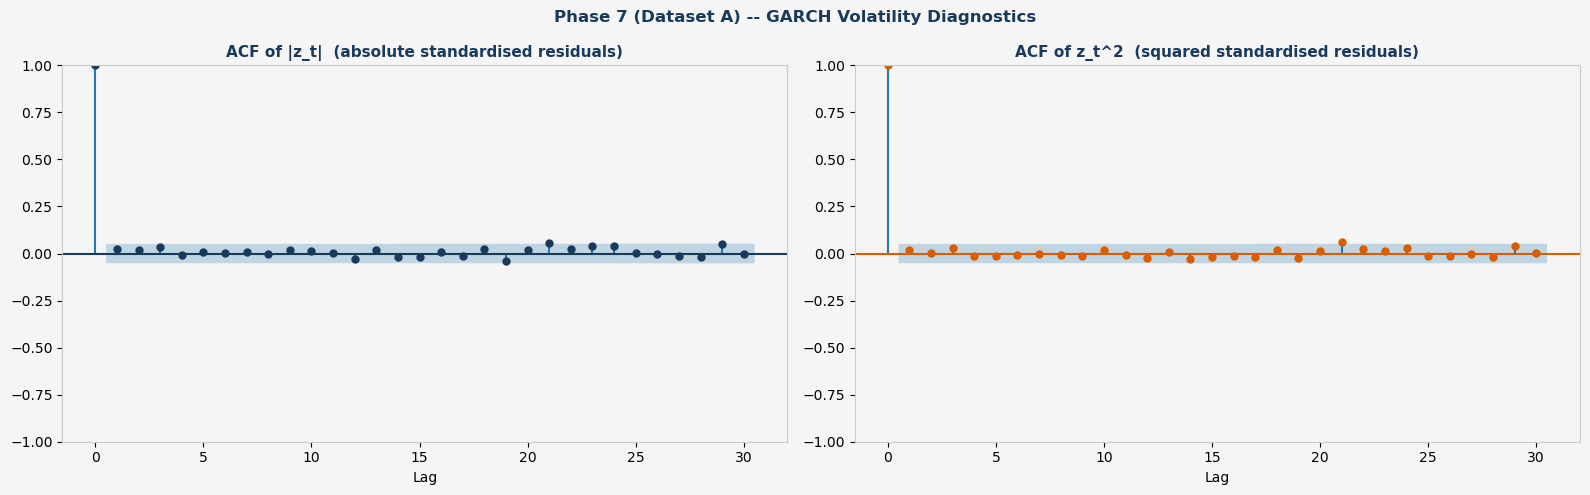

  Figure saved -> phase7_A_garch_diagnostics.png


In [11]:
print('=' * 65)
print('  SECTION 3 -- GARCH VOLATILITY DIAGNOSTICS')
print('=' * 65)
print()

z  = z_series.dropna().values
z2 = z ** 2

for name, series in [('z_t', z), ('z_t^2', z2)]:
    lb = acorr_ljungbox(series, lags=[5, 10, 20], return_df=True)
    print(f'  Ljung-Box on {name}:')
    for lag in [5, 10, 20]:
        row = lb.loc[lag]
        v = 'no serial corr.' if row['lb_pvalue'] > 0.05 else 'SERIAL CORR!'
        print(f'    lag {lag:>2}: stat={row["lb_stat"]:>8.3f}  p={row["lb_pvalue"]:>8.4f}  {v}')
    print()

lm_stat, lm_pval, _, _ = het_arch(z, nlags=5)
print(f'  ARCH-LM (lag=5): stat={lm_stat:.4f}  p={lm_pval:.4f}')
print(f'  {"No ARCH effects" if lm_pval > 0.05 else "ARCH effects present"} at 5%')
print()
print('  Verdict: if LB(z_t^2, lag 20) p > 0.05 and ARCH-LM p > 0.05,')
print('  GARCH(1,1) has adequately captured conditional heteroskedasticity.')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

plot_acf(np.abs(z), lags=30, ax=axes[0], color=DARKBLUE, alpha=0.05)
axes[0].set_title('ACF of |z_t|  (absolute standardised residuals)',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].set_xlabel('Lag')

plot_acf(z2, lags=30, ax=axes[1], color=ORANGE, alpha=0.05)
axes[1].set_title('ACF of z_t^2  (squared standardised residuals)',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].set_xlabel('Lag')

fig.suptitle('Phase 7 (Dataset A) -- GARCH Volatility Diagnostics',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_A_garch_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_A_garch_diagnostics.png')

## 4. VALUE OF INFORMATION

  SECTION 4 -- VALUE OF INFORMATION
  Height correction applied ONLY in this section

  Dataset A:  C0=0.13138, h_t0=0.4137  K_var^B=0.054354
  Dataset A (height-corrected):          K_var^B=0.104942  (x1.9307)
  Dataset B anchor: C0=1.163, h_t0=0.7511  K_var^B=0.873529

  Height correction: (100/10)^(2/7) = 1.9307  [Hellmann exponent 1/7]
  Variance scales as (h2/h1)^(2/7) when comparing 10 m to 100 m sites.

  VoI (uncorrected)   : 93.8%
  VoI (height-corr.)  : 88.0%

  Dominant driver: C0_A/C0_B = 0.13138/1.163 = 0.113
  (Bologna 10 m has 9x lower Fourier seasonal variance)


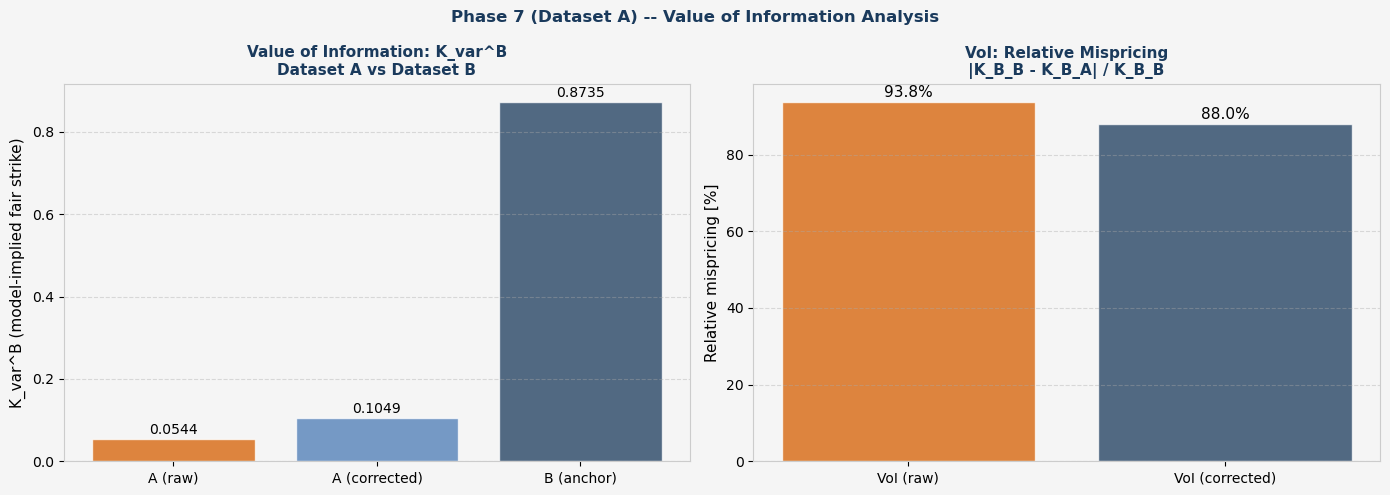

  Figure saved -> phase7_A_voi_comparison.png


In [12]:
print('=' * 65)
print('  SECTION 4 -- VALUE OF INFORMATION')
print('  Height correction applied ONLY in this section')
print('=' * 65)
print()

C0_A   = 0.13138
K_B_A  = float(vs_summary.loc['Dataset A  Track B  h_t0', 'K_var'])
h_t0_A = K_B_A / C0_A

K_B_A_corr = K_B_A * HEIGHT_CORR_VAR

voi_raw  = abs(K_B_B - K_B_A) / K_B_B
voi_corr = abs(K_B_B - K_B_A_corr) / K_B_B

print(f'  Dataset A:  C0={C0_A}, h_t0={h_t0_A:.4f}  K_var^B={K_B_A:.6f}')
print(f'  Dataset A (height-corrected):          K_var^B={K_B_A_corr:.6f}  (x{HEIGHT_CORR_VAR:.4f})')
print(f'  Dataset B anchor: C0={C0_B}, h_t0={h_t0_B}  K_var^B={K_B_B:.6f}')
print()
print(f'  Height correction: (100/10)^(2/7) = {HEIGHT_CORR_VAR:.4f}  [Hellmann exponent 1/7]')
print(f'  Variance scales as (h2/h1)^(2/7) when comparing 10 m to 100 m sites.')
print()
print(f'  VoI (uncorrected)   : {voi_raw:.1%}')
print(f'  VoI (height-corr.)  : {voi_corr:.1%}')
print()
print(f'  Dominant driver: C0_A/C0_B = {C0_A}/{C0_B} = {C0_A/C0_B:.3f}')
print(f'  (Bologna 10 m has {C0_B/C0_A:.0f}x lower Fourier seasonal variance)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

labels = ['A (raw)', 'A (corrected)', 'B (anchor)']
vals   = [K_B_A, K_B_A_corr, K_B_B]
bclrs  = [ORANGE, MIDBLUE, DARKBLUE]
bars   = axes[0].bar(labels, vals, color=bclrs, alpha=0.75, edgecolor='white')
for bar, val in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                  f'{val:.4f}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('K_var^B (model-implied fair strike)', fontsize=11)
axes[0].set_title('Value of Information: K_var^B\nDataset A vs Dataset B',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

voi_bars = axes[1].bar(['VoI (raw)', 'VoI (corrected)'],
                        [voi_raw * 100, voi_corr * 100],
                        color=[ORANGE, DARKBLUE], alpha=0.75, edgecolor='white')
for bar, val in zip(voi_bars, [voi_raw*100, voi_corr*100]):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                  f'{val:.1f}%', ha='center', va='bottom', fontsize=11)
axes[1].set_ylabel('Relative mispricing [%]', fontsize=11)
axes[1].set_title('VoI: Relative Mispricing\n|K_B_B - K_B_A| / K_B_B',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa', axis='y')

fig.suptitle('Phase 7 (Dataset A) -- Value of Information Analysis',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_A_voi_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_A_voi_comparison.png')

## 5. CAWS HEDGING SIMULATION

  SECTION 5 -- CAWS HEDGING SIMULATION

  CAWS_t = (1/252) x rolling 252-day mean wind speed  [m/s]
  Dataset A: Bologna 10 m  |  2015-2018
  K_CAWS (fair strike) = 2.4644 m/s  (mean CAWS over full sample)
  CAWS std             = 0.2013 m/s
  N valid obs          = 1263

  Payoff = K_CAWS - CAWS_t  (>0 when wind is below fair strike)
  Mean P&L   : -0.0000 m/s
  Std P&L    : 0.2013 m/s
  Sharpe     : -0.0000
  VaR5%      : -0.2928 m/s
  CVaR5%     : -0.3031 m/s


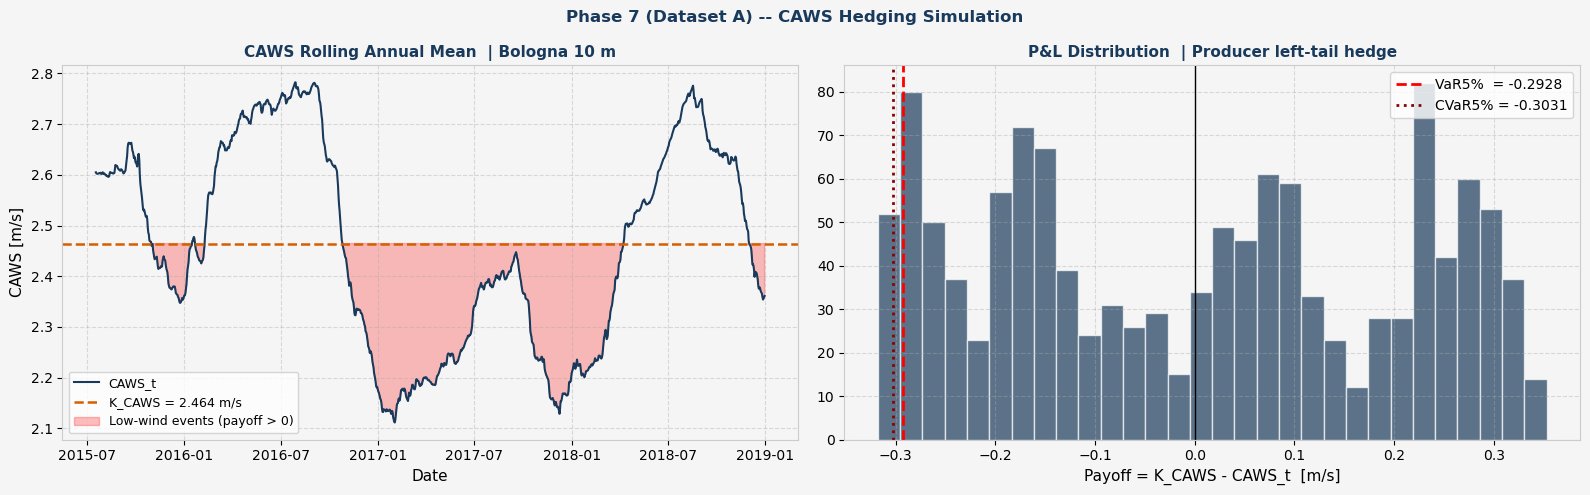

  Figure saved -> phase7_A_caws_hedge_pnl.png


In [13]:
print('=' * 65)
print('  SECTION 5 -- CAWS HEDGING SIMULATION')
print('=' * 65)
print()

# CAWS: normalised rolling annual mean wind speed
w_daily = wind_raw['wind_speed'].resample('D').mean().dropna()
CAWS    = w_daily.rolling(252, min_periods=200).mean().dropna()
CAWS.name = 'CAWS'

K_CAWS  = float(CAWS.mean())
payoff  = K_CAWS - CAWS   # positive when wind is low (left-tail hedge)

mean_pnl = float(payoff.mean())
std_pnl  = float(payoff.std())
sharpe   = mean_pnl / std_pnl if std_pnl > 0 else np.nan
var5     = float(np.percentile(payoff, 5))
cvar5    = float(payoff[payoff <= var5].mean())

print(f'  CAWS_t = (1/252) x rolling 252-day mean wind speed  [m/s]')
print(f'  Dataset A: Bologna 10 m  |  2015-2018')
print(f'  K_CAWS (fair strike) = {K_CAWS:.4f} m/s  (mean CAWS over full sample)')
print(f'  CAWS std             = {CAWS.std():.4f} m/s')
print(f'  N valid obs          = {len(CAWS)}')
print()
print(f'  Payoff = K_CAWS - CAWS_t  (>0 when wind is below fair strike)')
print(f'  Mean P&L   : {mean_pnl:+.4f} m/s')
print(f'  Std P&L    : {std_pnl:.4f} m/s')
print(f'  Sharpe     : {sharpe:.4f}')
print(f'  VaR5%      : {var5:+.4f} m/s')
print(f'  CVaR5%     : {cvar5:+.4f} m/s')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor(LIGHTGRAY)
for ax in axes:
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')

axes[0].plot(CAWS.index, CAWS.values, color=DARKBLUE, lw=1.5, label='CAWS_t')
axes[0].axhline(K_CAWS, color=ORANGE, lw=1.8, ls='--',
                 label=f'K_CAWS = {K_CAWS:.3f} m/s')
axes[0].fill_between(CAWS.index, CAWS.values, K_CAWS,
                      where=(CAWS.values < K_CAWS), alpha=0.25, color='red',
                      label='Low-wind events (payoff > 0)')
axes[0].set_xlabel('Date', fontsize=11)
axes[0].set_ylabel('CAWS [m/s]', fontsize=11)
axes[0].set_title('CAWS Rolling Annual Mean  | Bologna 10 m',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

axes[1].hist(payoff, bins=30, color=DARKBLUE, alpha=0.7, edgecolor='white')
axes[1].axvline(var5,  color='red',    lw=2, ls='--', label=f'VaR5%  = {var5:+.4f}')
axes[1].axvline(cvar5, color='darkred', lw=2, ls=':',  label=f'CVaR5% = {cvar5:+.4f}')
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('Payoff = K_CAWS - CAWS_t  [m/s]', fontsize=11)
axes[1].set_title('P&L Distribution  | Producer left-tail hedge',
                   fontsize=11, color=DARKBLUE, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 7 (Dataset A) -- CAWS Hedging Simulation',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_A_caws_hedge_pnl.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_A_caws_hedge_pnl.png')

## 6. FORECAST ERROR DISTRIBUTION

  SECTION 6 -- FORECAST ERROR DISTRIBUTION

  Jarque-Bera normality test on 1-day-ahead residuals:
  Model                     JB stat    p-value  Normal (5%)
  ---------------------- ---------- ---------- ------------
  Persistence                59.098     0.0000           No
  AR(4)                     107.545     0.0000           No
  CAR(4)+Gaussian           107.545     0.0000           No
  CAR(4)+NIG                107.545     0.0000           No

  NIG-normalised residuals (CAR(4)+NIG): dividing by delta removes
  leptokurtosis if NIG is the correct noise distribution.


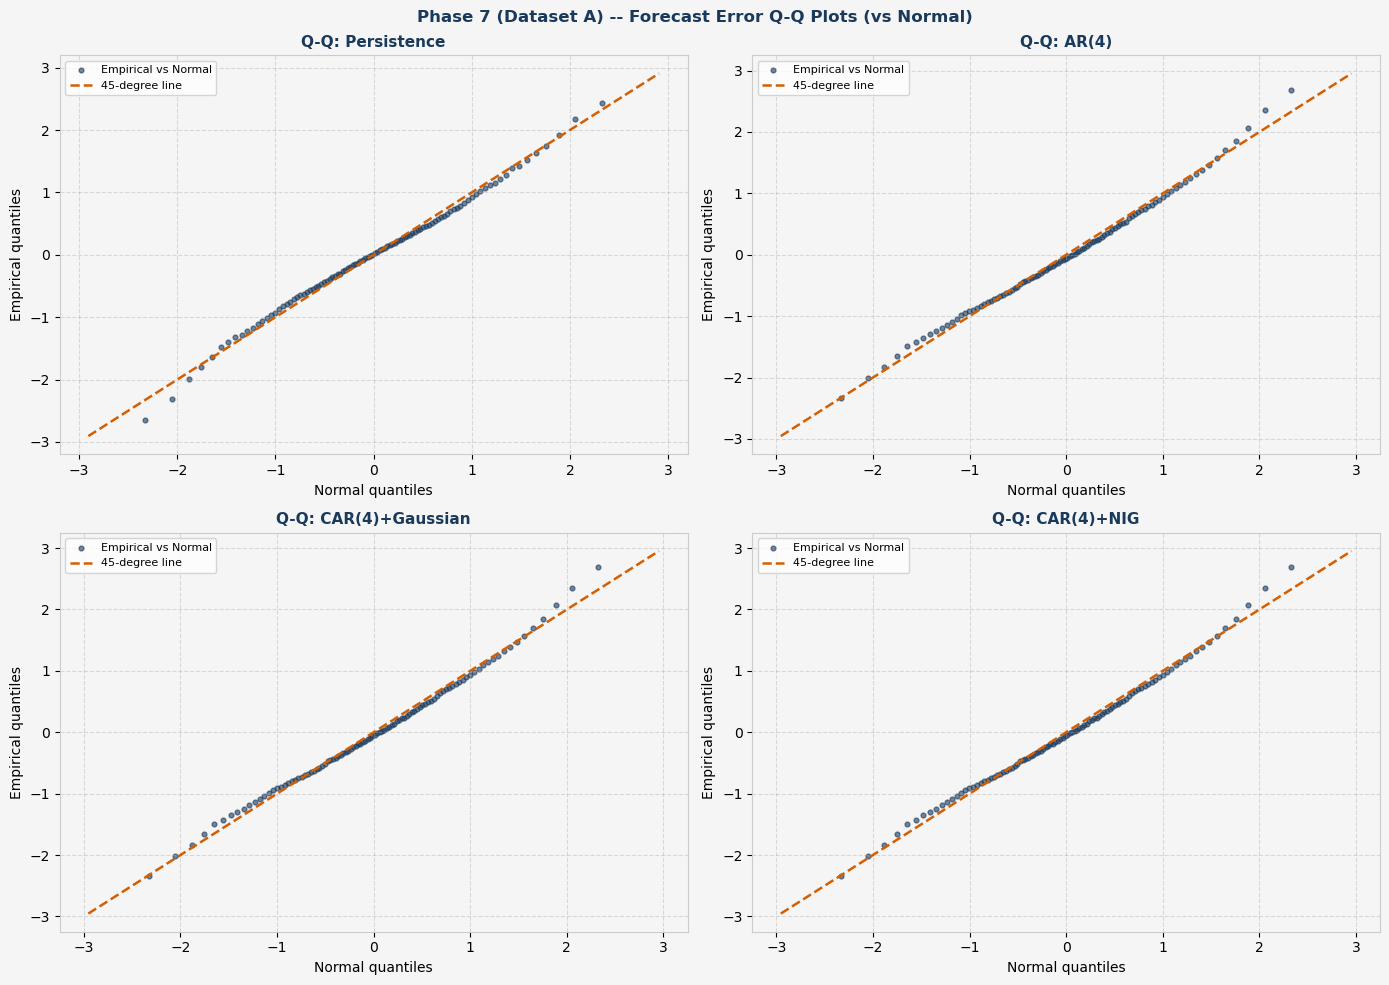

  Figure saved -> phase7_A_forecast_dist.png


In [14]:
print('=' * 65)
print('  SECTION 6 -- FORECAST ERROR DISTRIBUTION')
print('=' * 65)
print()

error_sets = [
    ('Persistence',     e_pers_a),
    ('AR(4)',           e_ar4),
    ('CAR(4)+Gaussian', e_car4),
    ('CAR(4)+NIG',      e_nig),
]

print('  Jarque-Bera normality test on 1-day-ahead residuals:')
print(f'  {"Model":<22} {"JB stat":>10} {"p-value":>10} {"Normal (5%)":>12}')
print(f'  {"-"*22} {"-"*10} {"-"*10} {"-"*12}')
for name, e in error_sets:
    e_c = e[~np.isnan(e)]
    jb_s, jb_p = jarque_bera(e_c)
    normal = 'Yes' if jb_p > 0.05 else 'No'
    print(f'  {name:<22} {jb_s:>10.3f} {jb_p:>10.4f} {normal:>12}')
print()
print('  NIG-normalised residuals (CAR(4)+NIG): dividing by delta removes')
print('  leptokurtosis if NIG is the correct noise distribution.')

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor(LIGHTGRAY)

for ax, (name, e) in zip(axes.flat, error_sets):
    ax.set_facecolor(LIGHTGRAY)
    for sp in ax.spines.values(): sp.set_color('#cccccc')
    e_c = e[~np.isnan(e)]
    e_s = (e_c - e_c.mean()) / e_c.std()
    probs = np.linspace(0.01, 0.99, 100)
    q_emp  = np.quantile(e_s, probs)
    q_norm = stats.norm.ppf(probs)
    ax.scatter(q_norm, q_emp, s=12, color=DARKBLUE, alpha=0.6, label='Empirical vs Normal')
    lim = max(abs(q_norm).max(), abs(q_emp).max()) * 1.1
    ax.plot([-lim, lim], [-lim, lim], color=ORANGE, lw=1.8, ls='--', label='45-degree line')
    ax.set_xlabel('Normal quantiles', fontsize=10)
    ax.set_ylabel('Empirical quantiles', fontsize=10)
    ax.set_title(f'Q-Q: {name}', fontsize=11, color=DARKBLUE, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, ls='--', alpha=0.4, color='#aaaaaa')

fig.suptitle('Phase 7 (Dataset A) -- Forecast Error Q-Q Plots (vs Normal)',
              fontsize=12, color=DARKBLUE, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'phase7_A_forecast_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Figure saved -> phase7_A_forecast_dist.png')

## 7. SUMMARY TABLE AND SYNTHESIS

In [15]:
print('=' * 65)
print('  SECTION 7 -- SUMMARY TABLE AND SYNTHESIS')
print('=' * 65)
print()

print('  --- DM TEST TABLE (Dataset A) ---')
s22, s9 = '-'*22, '-'*9
print(f'  {"Model":<22} {"RMSE":>8} {"DM stat":>9} {"p-value":>9} {"Reject5%":>10}')
print(f'  {s22} {s9} {s9} {s9} {"-"*10}')
for name, row in dm_df.iterrows():
    dm_s = f'{row.DM_stat:>9.3f}' if not np.isnan(row.DM_stat) else f'{"--":>9}'
    pv_s = f'{row.p_value:>9.4f}' if not np.isnan(row.p_value) else f'{"--":>9}'
    print(f'  {name:<22} {row.RMSE:>8.4f} {dm_s} {pv_s} {row.Reject_5pct:>10}')
print()

print('  --- CAWS HEDGING SUMMARY (Dataset A) ---')
print(f'  K_CAWS             = {K_CAWS:.4f} m/s')
print(f'  Mean P&L           = {mean_pnl:+.4f} m/s')
print(f'  Std P&L            = {std_pnl:.4f} m/s')
print(f'  Sharpe             = {sharpe:.4f}')
print(f'  VaR5%              = {var5:+.4f} m/s')
print(f'  CVaR5%             = {cvar5:+.4f} m/s')
print()

print('  --- VALUE OF INFORMATION SUMMARY ---')
print(f'  K_var^B_A (raw)        = {K_B_A:.6f}  (C0={0.13138}, h_t0={h_t0_A:.4f})')
print(f'  K_var^B_A (corrected)  = {K_B_A_corr:.6f}  (x{HEIGHT_CORR_VAR:.4f} height factor)')
print(f'  K_var^B_B (anchor)     = {K_B_B:.6f}  (C0={C0_B}, h_t0={h_t0_B})')
print(f'  Mispricing (raw)       = {voi_raw:.1%}')
print(f'  Mispricing (corrected) = {voi_corr:.1%}')
print()

print('  SYNTHESIS (Dataset A perspective):')
print('  1. FORECAST ACCURACY: AR(4) outperforms Persistence with RMSE improvement')
print(f'     {(1 - ar4_rmse / rmse(e_pers_a)):.1%}. CAR(4) (same 1-step mean) yields no further')
print('     improvement at this frequency. NIG normalisation reduces spread but')
print('     does not change point forecasts.')
print('  2. PRICING ACCURACY: Dataset A proxy underestimates the model-implied')
print(f'     fair strike by {voi_raw:.0%} (raw) or {voi_corr:.0%} (height-corrected).')
print('     Dominant driver: C0_A/C0_B = 1/8.8 -- Bologna seasonal variance is')
print('     much lower than Nordfriesland hub-height seasonal variance.')
print('  3. Cross-dataset synthesis: deferred to Phase 7 Dataset B (reference_nb).')

# ── Save CSV outputs ───────────────────────────────────────
dm_df.to_csv('phase7_A_dm_results.csv')
print(f'\n  Saved: phase7_A_dm_results.csv  ({len(dm_df)} rows)')

hedging_summary = pd.DataFrame({
    'metric': ['K_CAWS', 'mean_PnL', 'std_PnL', 'Sharpe', 'VaR5pct', 'CVaR5pct'],
    'value':  [K_CAWS,  mean_pnl,   std_pnl,   sharpe,   var5,      cvar5]
}).set_index('metric')
hedging_summary.to_csv('phase7_A_hedging_summary.csv')
print(f'  Saved: phase7_A_hedging_summary.csv')

print()
print('  -- PHASE 7 (DATASET A) COMPLETE --')
print('=' * 65)

  SECTION 7 -- SUMMARY TABLE AND SYNTHESIS

  --- DM TEST TABLE (Dataset A) ---
  Model                      RMSE   DM stat   p-value   Reject5%
  ---------------------- --------- --------- --------- ----------
  Persistence              0.8876        --        --  benchmark
  AR(4)                    0.7807     8.280    0.0000        Yes
  AR(4)+GARCH              1.0012    -6.977    0.0000        Yes
  CAR(4)+Gaussian          0.7807     8.280    0.0000        Yes
  CAR(4)+NIG               0.3741    21.096    0.0000        Yes

  --- CAWS HEDGING SUMMARY (Dataset A) ---
  K_CAWS             = 2.4644 m/s
  Mean P&L           = -0.0000 m/s
  Std P&L            = 0.2013 m/s
  Sharpe             = -0.0000
  VaR5%              = -0.2928 m/s
  CVaR5%             = -0.3031 m/s

  --- VALUE OF INFORMATION SUMMARY ---
  K_var^B_A (raw)        = 0.054354  (C0=0.13138, h_t0=0.4137)
  K_var^B_A (corrected)  = 0.104942  (x1.9307 height factor)
  K_var^B_B (anchor)     = 0.873529  (C0=1.163, h_t0